In [148]:
# This notebook can be used to evaluate the results of a GEMPIC simulation and compare the results if a 
# different number of MPI processes is used. 
# The example 'Slices' stored in gempic/post_processing/ParticlePlotfiles can be used and are implemented 
# here by default. If you want to use a different source, change the path in the loading process accordingly.
# Set the user parameters in the following Cell.

In [149]:
# User Parameters
step = '100' # Number of the step to evaluate. In the example data steps 0, 10, 20, 30, 40, 50, 60,
# 70, 80, 90, 100 are available

In [150]:
# Importing and preparing necessary libraries
import yt
import matplotlib.pylab as plt
import numpy as np
yt.funcs.mylog.setLevel(0)

In [151]:
# Loading YT data sets
ds_1 = yt.load('/home/irga/build/gempic/ParticlePlotfiles/Slices_1_00' + step)
ds_4 = yt.load('/home/irga/build/gempic/ParticlePlotfiles/Slices_4_00' + step)

In [152]:
# Here we see the available data (shown for data set 1 as this is always equal)
ds_1.field_list

[('all', 'particle_cpu'),
 ('all', 'particle_id'),
 ('all', 'particle_position_x'),
 ('all', 'particle_position_y'),
 ('all', 'particle_position_z'),
 ('all', 'particle_vx'),
 ('all', 'particle_vy'),
 ('all', 'particle_vz'),
 ('all', 'particle_weight'),
 ('boxlib', 'B_x'),
 ('boxlib', 'B_y'),
 ('boxlib', 'B_z'),
 ('boxlib', 'E_x'),
 ('boxlib', 'E_y'),
 ('boxlib', 'E_z'),
 ('electrons', 'particle_cpu'),
 ('electrons', 'particle_id'),
 ('electrons', 'particle_position_x'),
 ('electrons', 'particle_position_y'),
 ('electrons', 'particle_position_z'),
 ('electrons', 'particle_vx'),
 ('electrons', 'particle_vy'),
 ('electrons', 'particle_vz'),
 ('electrons', 'particle_weight')]

In [153]:
# Number of particles
print (ds_1.particle_type_counts)
print (ds_4.particle_type_counts)

{'electrons': 153600}
{'electrons': 153600}


In [154]:
# Get Particle Positions and Velocities
data_1 = ds_1.covering_grid( 0, ds_1.domain_left_edge, ds_1.domain_dimensions )
particle_position_x_1 = data_1['electrons','particle_position_x']
particle_position_y_1 = data_1['electrons','particle_position_y']
particle_position_z_1 = data_1['electrons','particle_position_z']

data_4 = ds_4.covering_grid( 0, ds_4.domain_left_edge, ds_4.domain_dimensions )
particle_position_x_4 = data_4['electrons','particle_position_x']
particle_position_y_4 = data_4['electrons','particle_position_y']
particle_position_z_4 = data_4['electrons','particle_position_z']

particle_v_x_1 = data_1['electrons','particle_vx']
particle_v_y_1 = data_1['electrons','particle_vy']
particle_v_z_1 = data_1['electrons','particle_vz']

particle_v_x_4 = data_4['electrons','particle_vx']
particle_v_y_4 = data_4['electrons','particle_vy']
particle_v_z_4 = data_4['electrons','particle_vz']

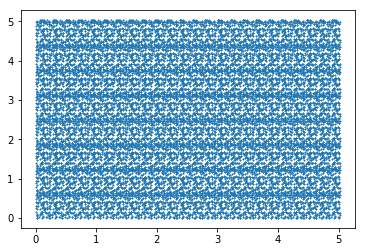

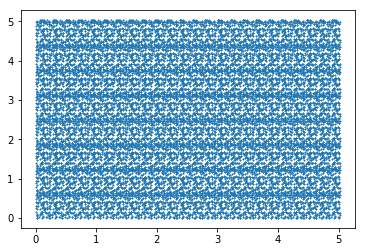

In [155]:
#Plot particle position

plt.scatter(particle_position_x_1, particle_position_y_1, s = 0.1)
plt.figure()
plt.scatter(particle_position_x_4, particle_position_y_4, s = 0.1)

(array([ 1536.,  1536.,     0.,     0.,  1536.,  3072.,     0.,  7680.,
         4608.,  9216.,  7680., 10752., 18432.,  7680., 13824.,  6144.,
        12288.,  6144., 13824.,  7680.,  6144.,  6144.,  1536.,     0.,
         6144.]),
 YTArray([-0.04081071, -0.03795568, -0.03510065, -0.03224562, -0.02939059,
          -0.02653556, -0.02368053, -0.0208255 , -0.01797046, -0.01511543,
          -0.0122604 , -0.00940537, -0.00655034, -0.00369531, -0.00084028,
           0.00201475,  0.00486979,  0.00772482,  0.01057985,  0.01343488,
           0.01628991,  0.01914494,  0.02199997,  0.024855  ,  0.02771003,
           0.03056507]) (dimensionless),
 <a list of 25 Patch objects>)

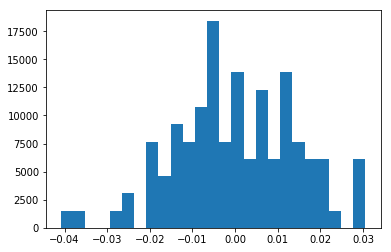

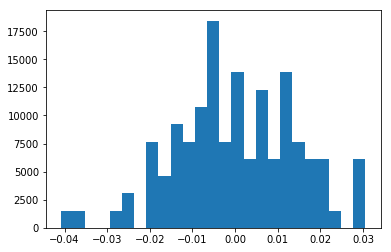

In [156]:
#Plot velocity distributions

plt.hist(particle_v_x_1, bins=25)
plt.figure()
plt.hist(particle_v_x_4, bins=25)

yt : [WARNING  ] 2020-07-20 16:56:07,966 Plot image for field ('boxlib', 'B_z') has both positive and negative values. Min = -0.001142, Max = 0.001158.
yt : [WARNING  ] 2020-07-20 16:56:07,967 Switching to symlog colorbar scaling unless linear scaling is specified later



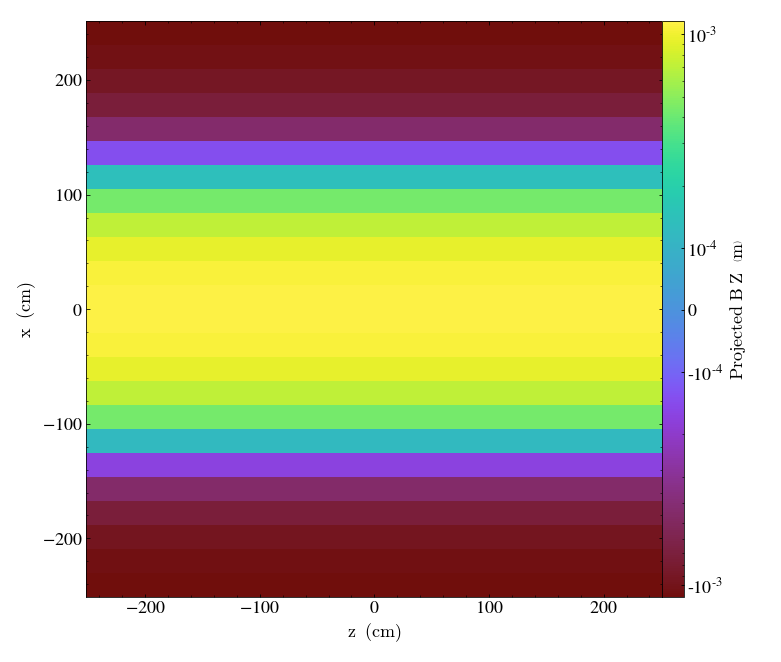

yt : [WARNING  ] 2020-07-20 16:56:08,645 Plot image for field ('boxlib', 'B_z') has both positive and negative values. Min = -0.001142, Max = 0.001158.
yt : [WARNING  ] 2020-07-20 16:56:08,648 Switching to symlog colorbar scaling unless linear scaling is specified later



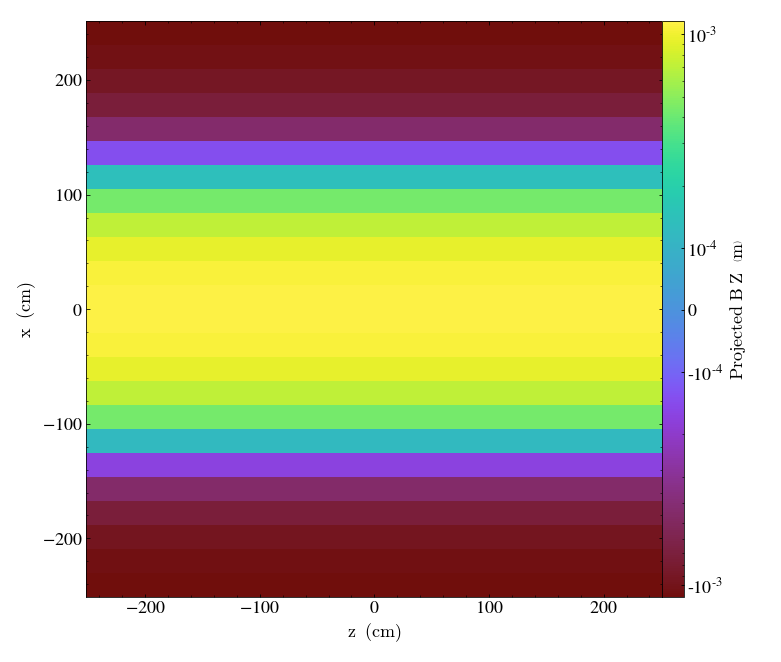

In [157]:
#Plot B_z field (slice along y-axis)

p = yt.ProjectionPlot(ds_1, "y", "B_z")
p.show()
p = yt.ProjectionPlot(ds_4, "y", "B_z")
p.show()

In [158]:
# Maximum of the difference in B-Fields

B_z_diff = data_1['boxlib','B_z']-data_4['boxlib','B_z']
np.max(np.abs(B_z_diff))

5.4267191868656584e-14 dimensionless